In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.1 MB/s eta 0:00:00a 0:00:01


In [2]:
from ultralytics import YOLO

import os

dataset_path = "/kaggle/input/datasets/reemmousa87/anti-uav-rgb-yolo/Anti-UAV-RGB-YOLO_fit"

for split in ["train", "val", "test"]:
    imgs = len(os.listdir(f"{dataset_path}/images/{split}"))
    labels = len(os.listdir(f"{dataset_path}/labels/{split}"))
    print(split, "Images:", imgs, "Labels:", labels)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
train Images: 14972 Labels: 14972
val Images: 6208 Labels: 6208
test Images: 8547 Labels: 8547


In [3]:
yaml_path = "/kaggle/working/anti_uav.yaml"

yaml_content = """
path: /kaggle/input/datasets/reemmousa87/anti-uav-rgb-yolo/Anti-UAV-RGB-YOLO_fit

train: images/train
val: images/val
test: images/test

names:
  0: drone
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(open(yaml_path).read())


path: /kaggle/input/datasets/reemmousa87/anti-uav-rgb-yolo/Anti-UAV-RGB-YOLO_fit

train: images/train
val: images/val
test: images/test

names:
  0: drone



In [4]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

In [5]:
from pathlib import Path

label_dir = Path("/kaggle/input/datasets/reemmousa87/anti-uav-rgb-yolo/Anti-UAV-RGB-YOLO_fit/labels/train")

labels = list(label_dir.glob("*.txt"))

print("Number of labels:", len(labels))

print(labels[0].read_text())

Number of labels: 14972
0 0.47109375 0.25601851851851853 0.05572916666666667 0.03981481481481482



In [6]:
results = model.train(
    data="/kaggle/working/anti_uav.yaml",
    epochs=35,
    imgsz=640,
    batch=18,
    optimizer="AdamW",
    lr0=0.001,
    patience=8,
    device=[0, 1],
    workers=2,
    project="Anti_UAV_YOLO11m",
    verbose = True,
    name="exp1",
    save=True,
    plots=True
)

Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=18, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/anti_uav.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

In [8]:
model = YOLO(
"/kaggle/working/runs/detect/Anti_UAV_YOLO11m/exp1/weights/best.pt"
)

metrics = model.val(
    data="/kaggle/working/anti_uav.yaml",
    split="test",
    plots=True
)

print(metrics)

Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.2 ms, read: 22.7±2.5 MB/s, size: 115.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/reemmousa87/anti-uav-rgb-yolo/Anti-UAV-RGB-YOLO_fit/labels/test... 8547 images, 559 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8547/8547 237.9it/s 35.9s0.1ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/reemmousa87/anti-uav-rgb-yolo/Anti-UAV-RGB-YOLO_fit/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 535/535 3.1it/s 2:510.3ss
                   all       8547       7988      0.964       0.93      0.956      0.554
Speed: 0.5ms preprocess, 16.4m

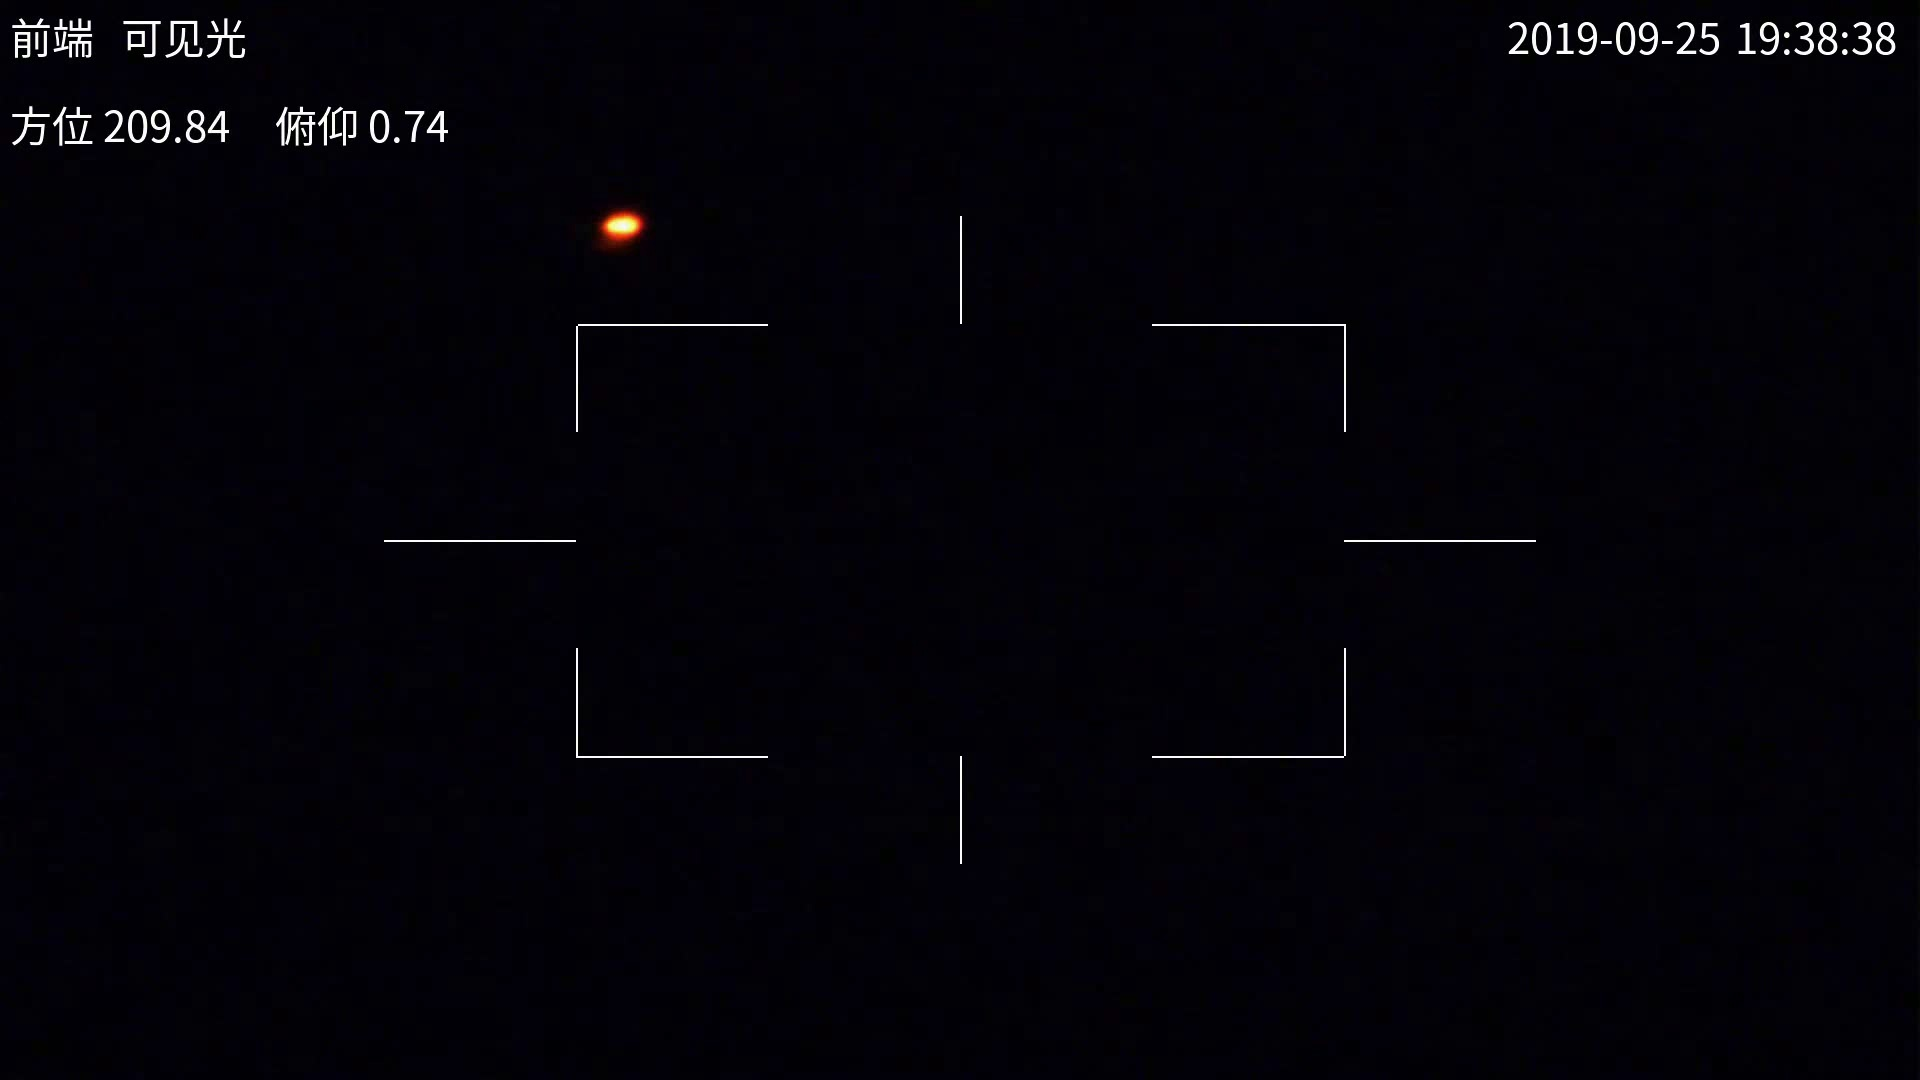

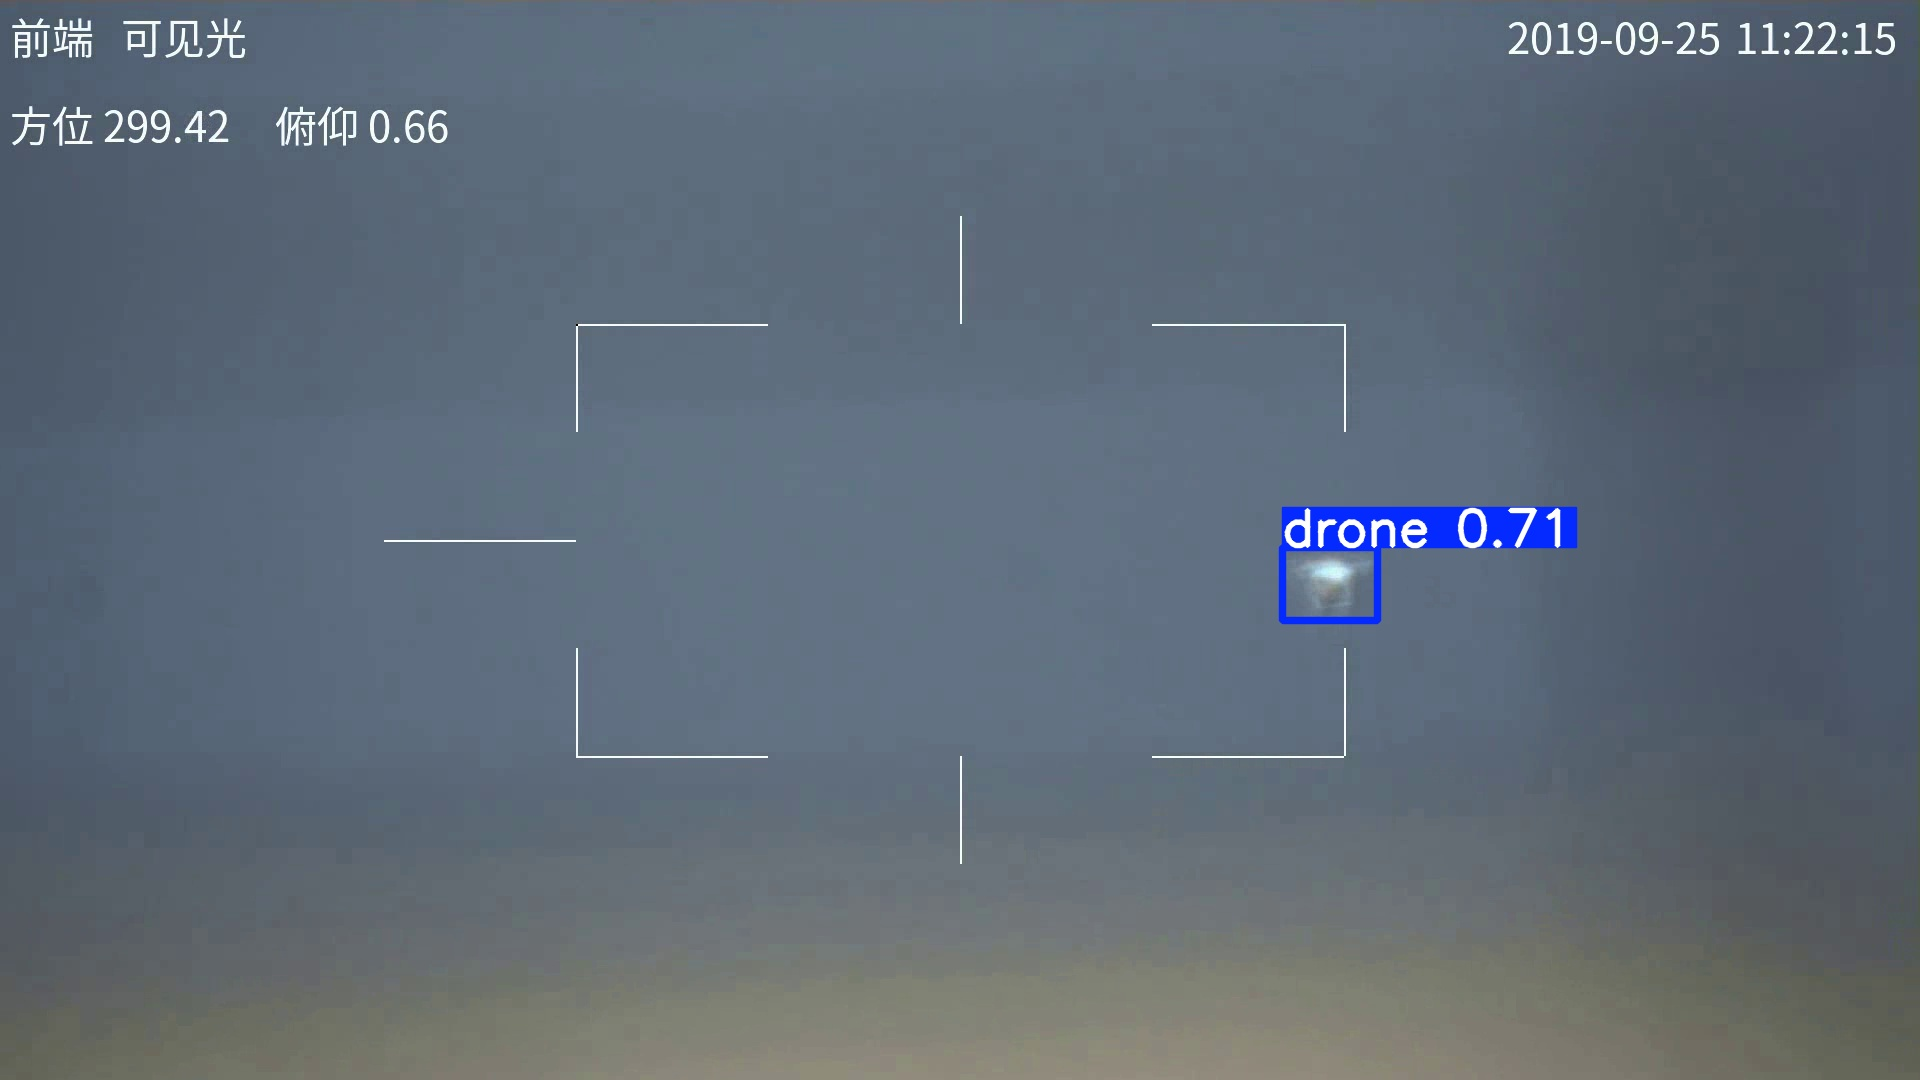

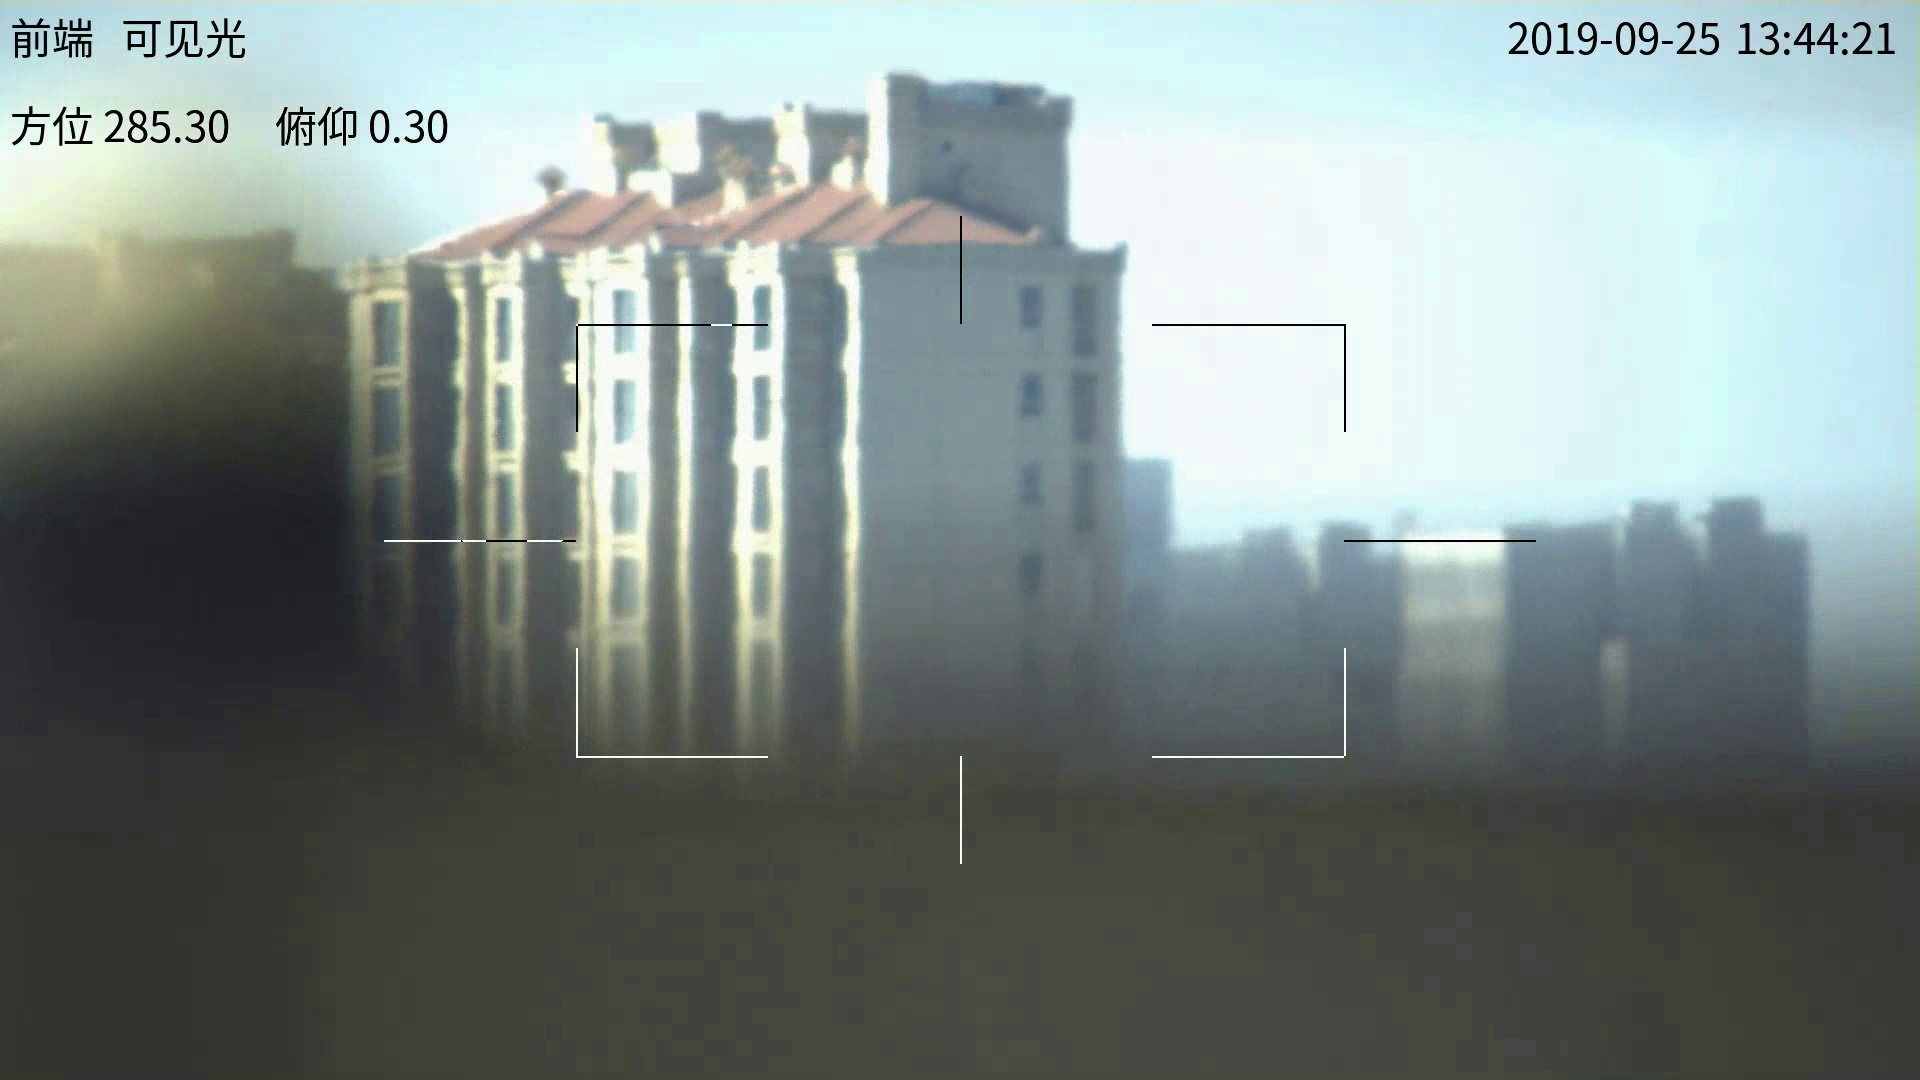

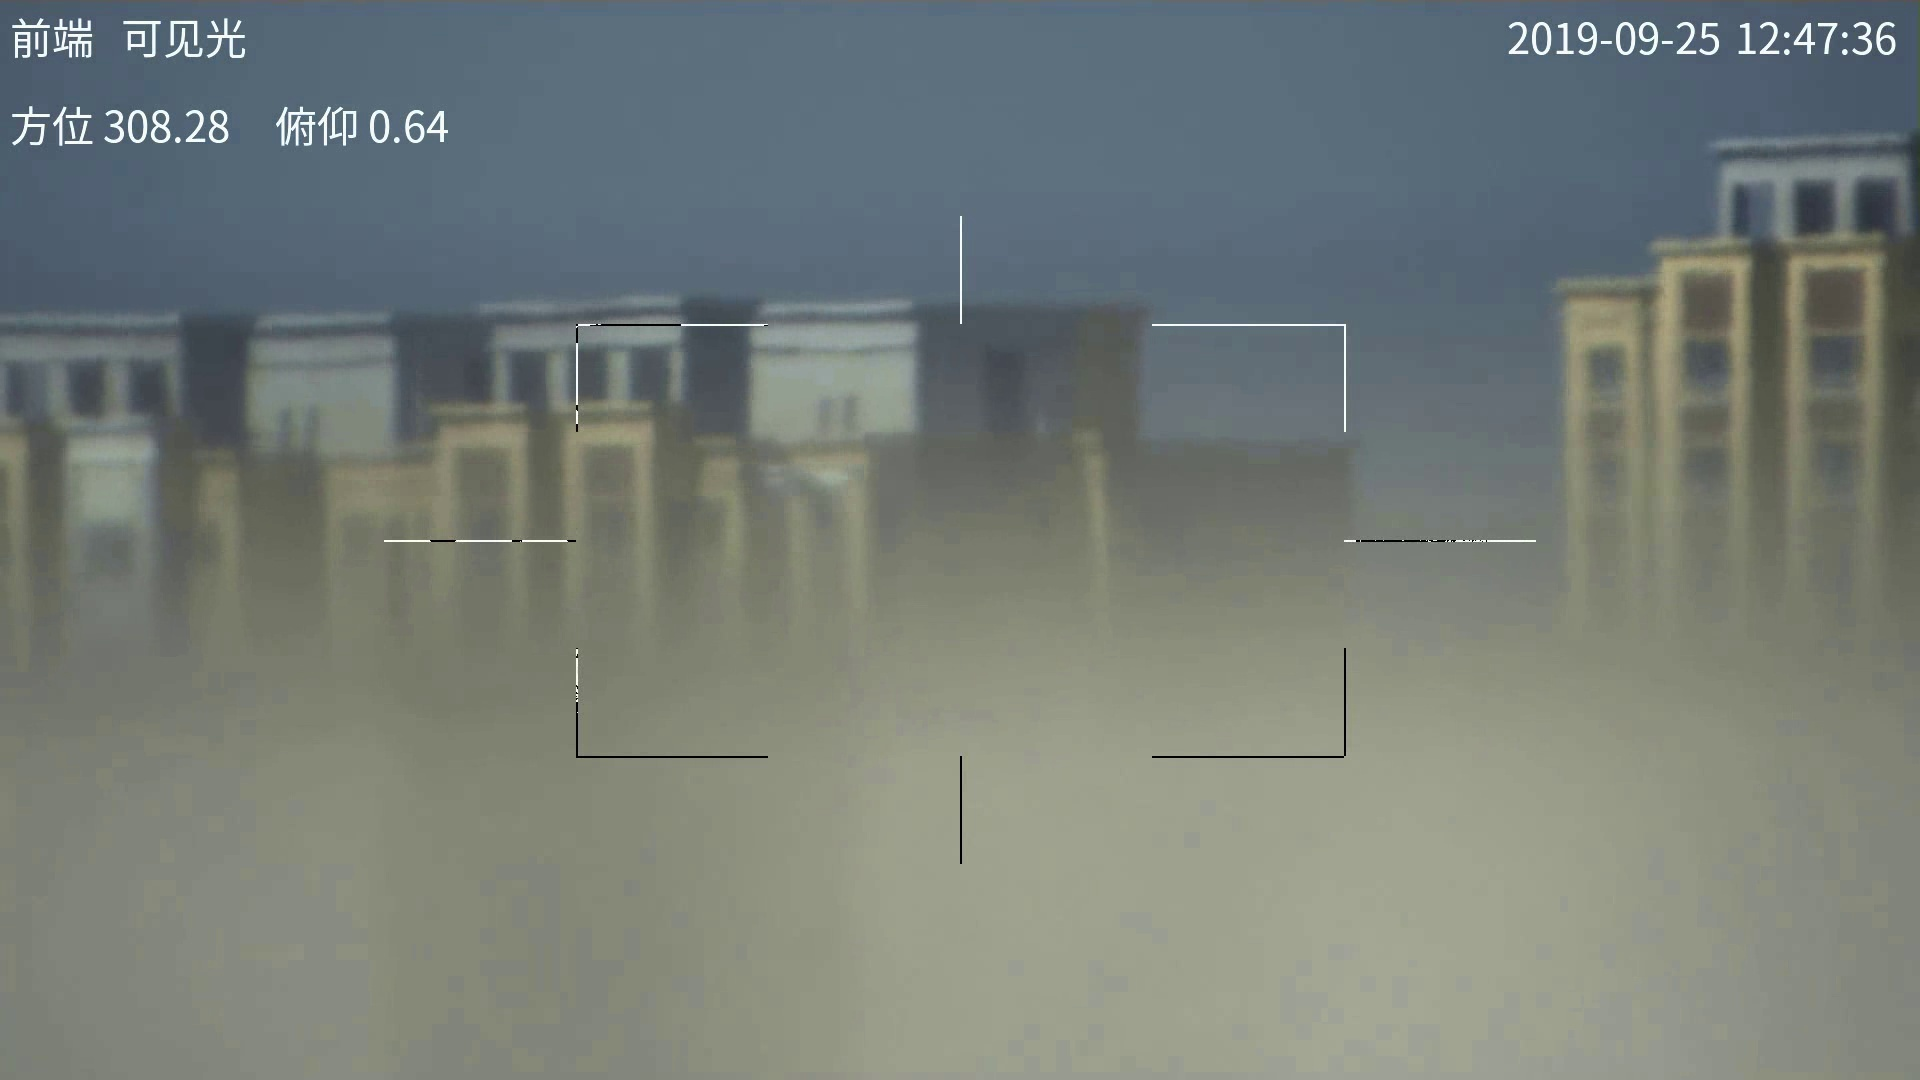

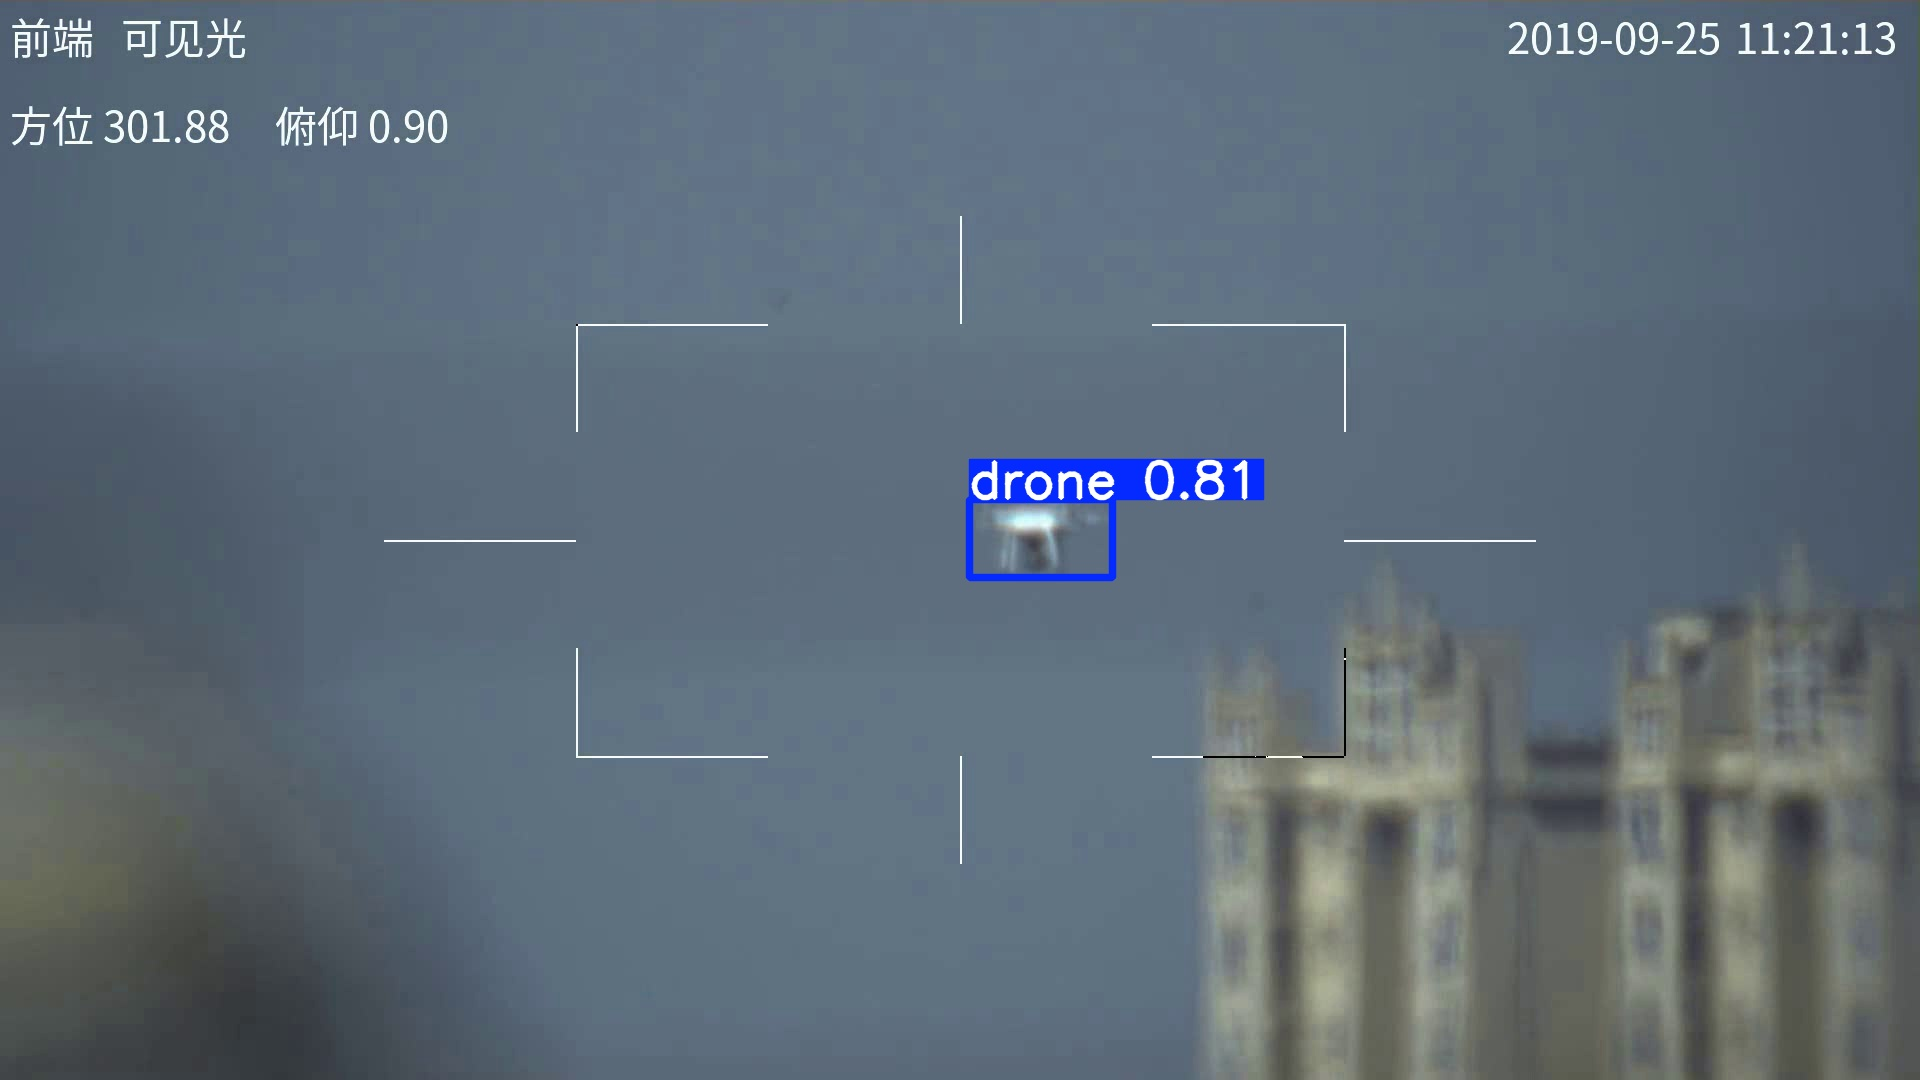

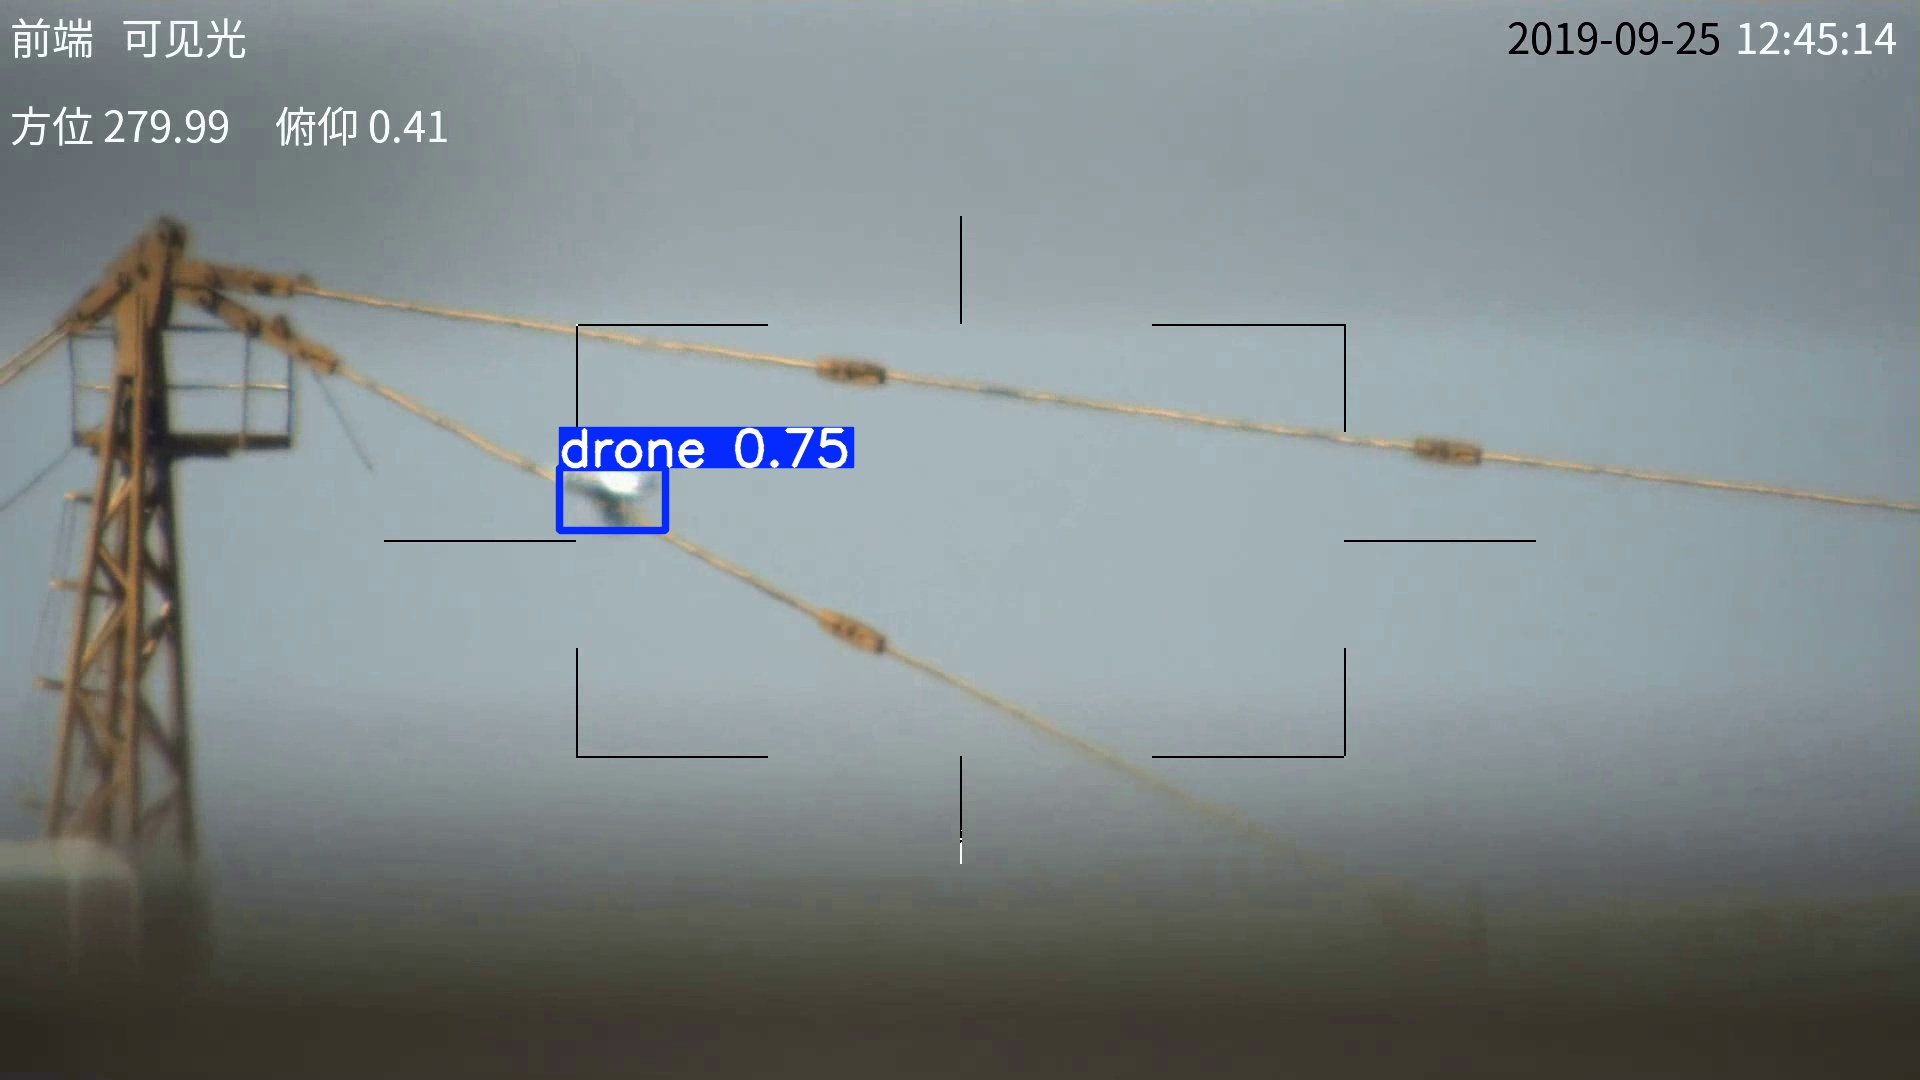

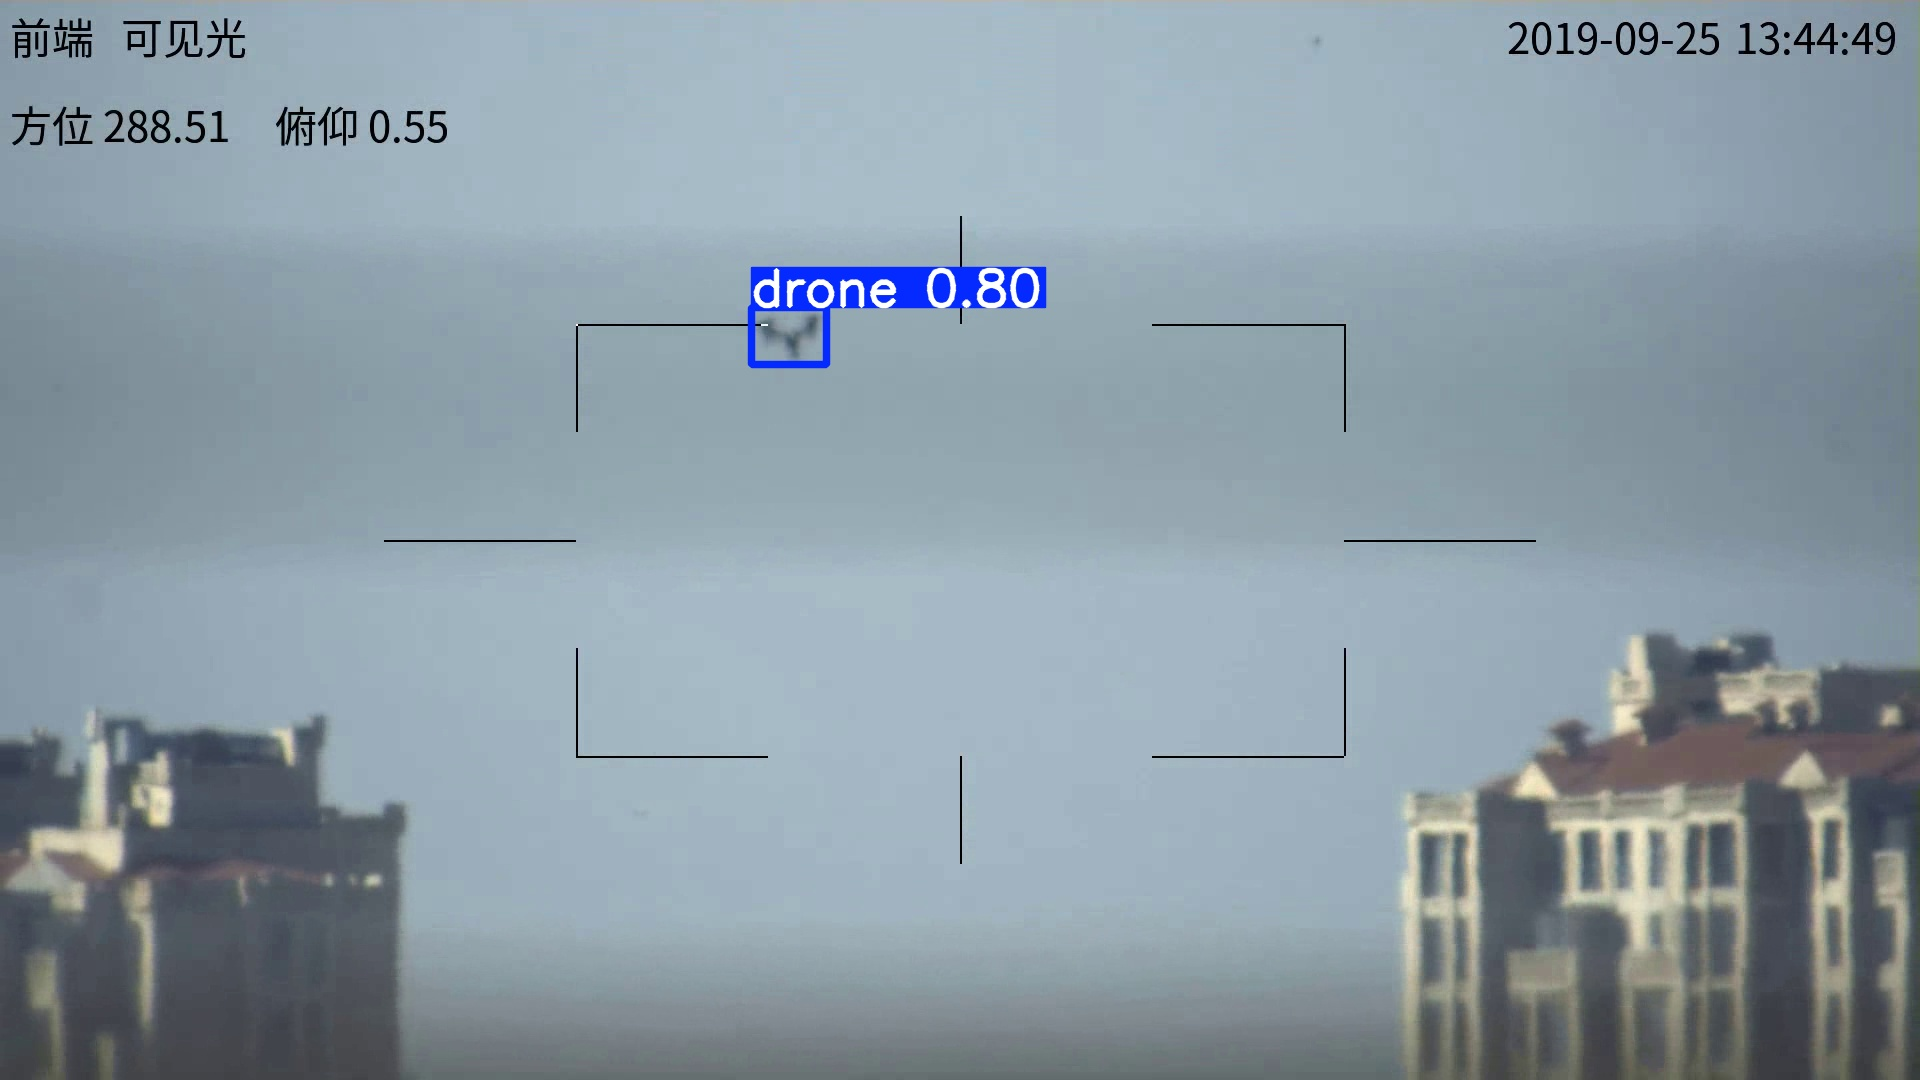

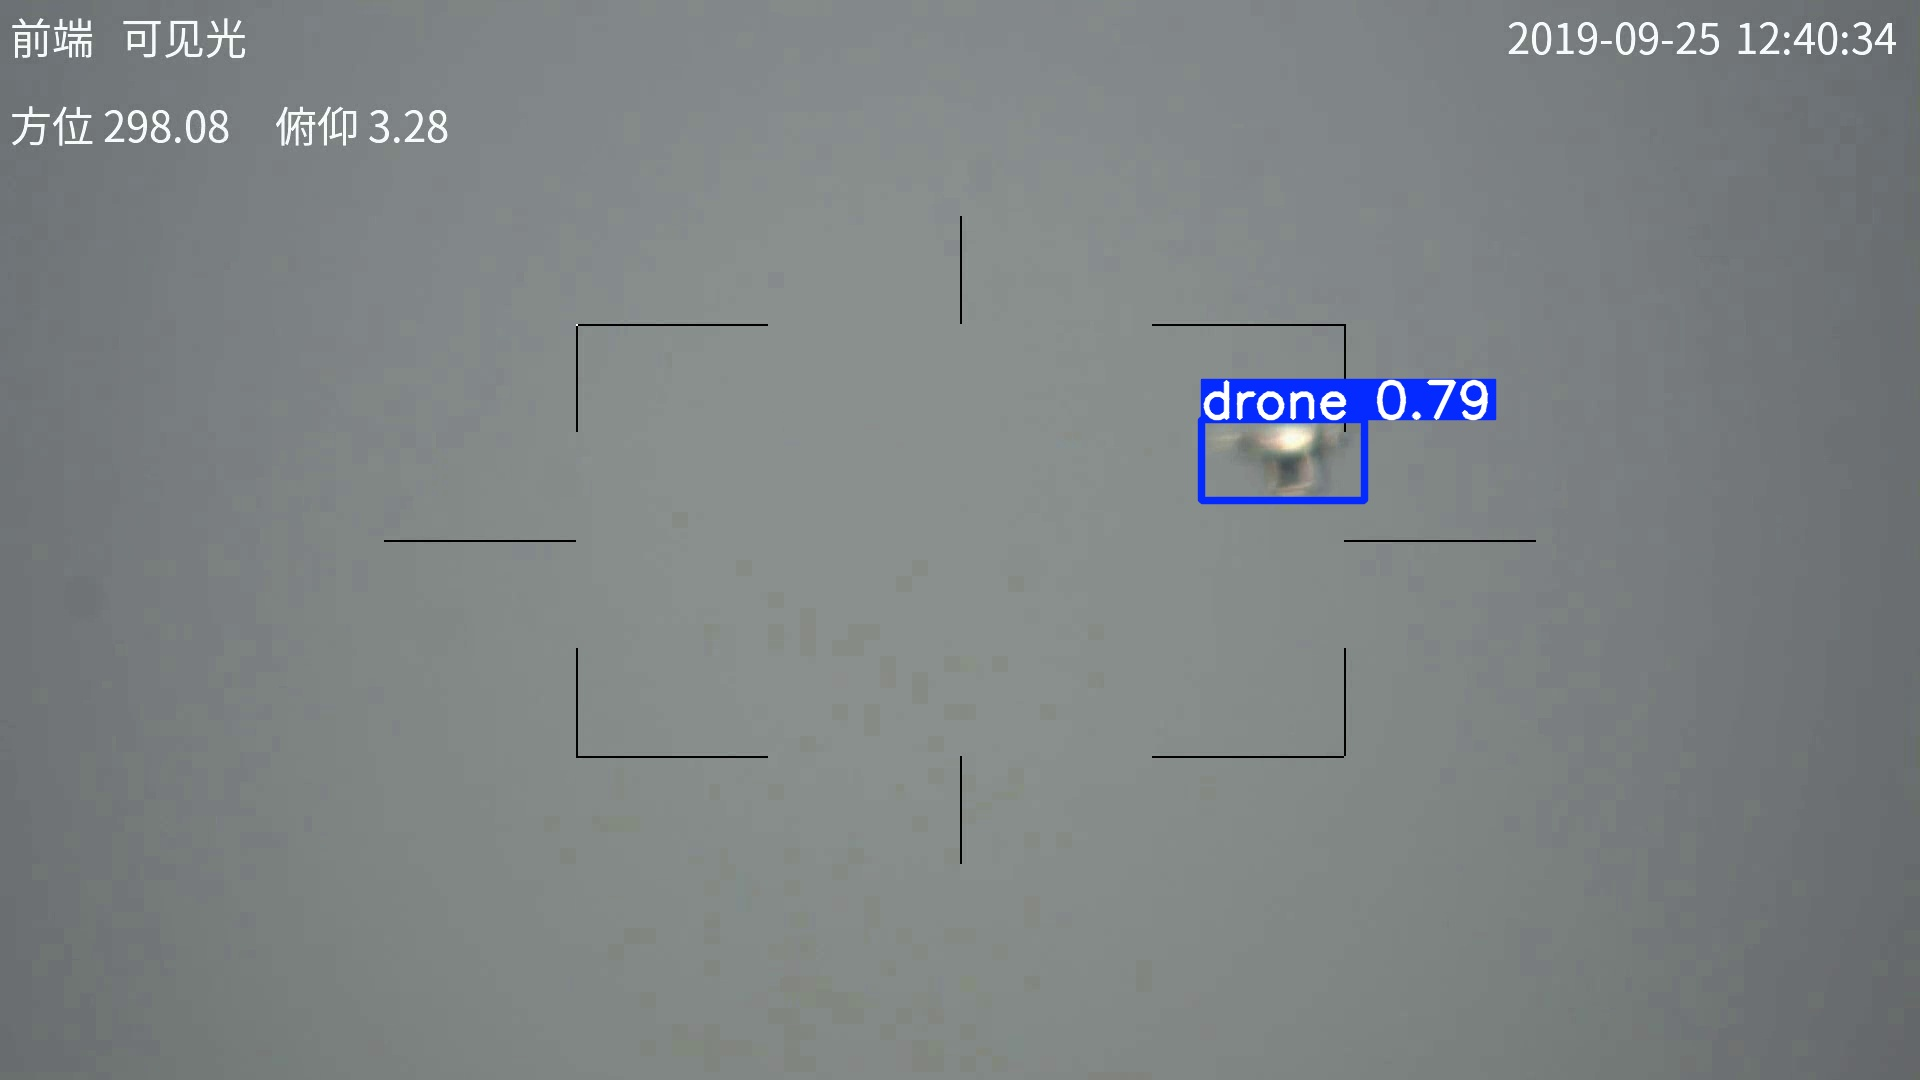

In [5]:
from IPython.display import Image, display
from pathlib import Path

pred_dir = Path("/kaggle/working/runs/detect/predict")

for img in list(pred_dir.glob("*.jpg"))[:8]:
    display(Image(filename=str(img)))

In [8]:
from ultralytics import YOLO
from pathlib import Path
import random

# Load the best trained model
model = YOLO("/kaggle/working/runs/detect/Anti_UAV_YOLO11m/exp1/weights/best.pt")

# Test images directory
test_dir = Path("/kaggle/input/datasets/reemmousa87/anti-uav-rgb-yolo/Anti-UAV-RGB-YOLO_fit/images/test")

# Sample 20 random images
sample_images = random.sample(list(test_dir.glob("*")), 20)

# Run predictions
results = model.predict(
    source=[str(img) for img in sample_images],
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=False,
    device=0
)


0: 384x640 1 drone, 15.7ms
1: 384x640 1 drone, 15.7ms
2: 384x640 1 drone, 15.7ms
3: 384x640 1 drone, 15.7ms
4: 384x640 (no detections), 15.7ms
5: 384x640 1 drone, 15.7ms
6: 384x640 1 drone, 15.7ms
7: 384x640 1 drone, 15.7ms
8: 384x640 1 drone, 15.7ms
9: 384x640 1 drone, 15.7ms
10: 384x640 1 drone, 15.7ms
11: 384x640 1 drone, 15.7ms
12: 384x640 1 drone, 15.7ms
13: 384x640 1 drone, 15.7ms
14: 384x640 1 drone, 15.7ms
15: 384x640 1 drone, 15.7ms
16: 384x640 (no detections), 15.7ms
17: 384x640 1 drone, 15.7ms
18: 384x640 1 drone, 15.7ms
19: 384x640 1 drone, 15.7ms
Speed: 3.3ms preprocess, 15.7ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /kaggle/working/runs/detect/predict-2


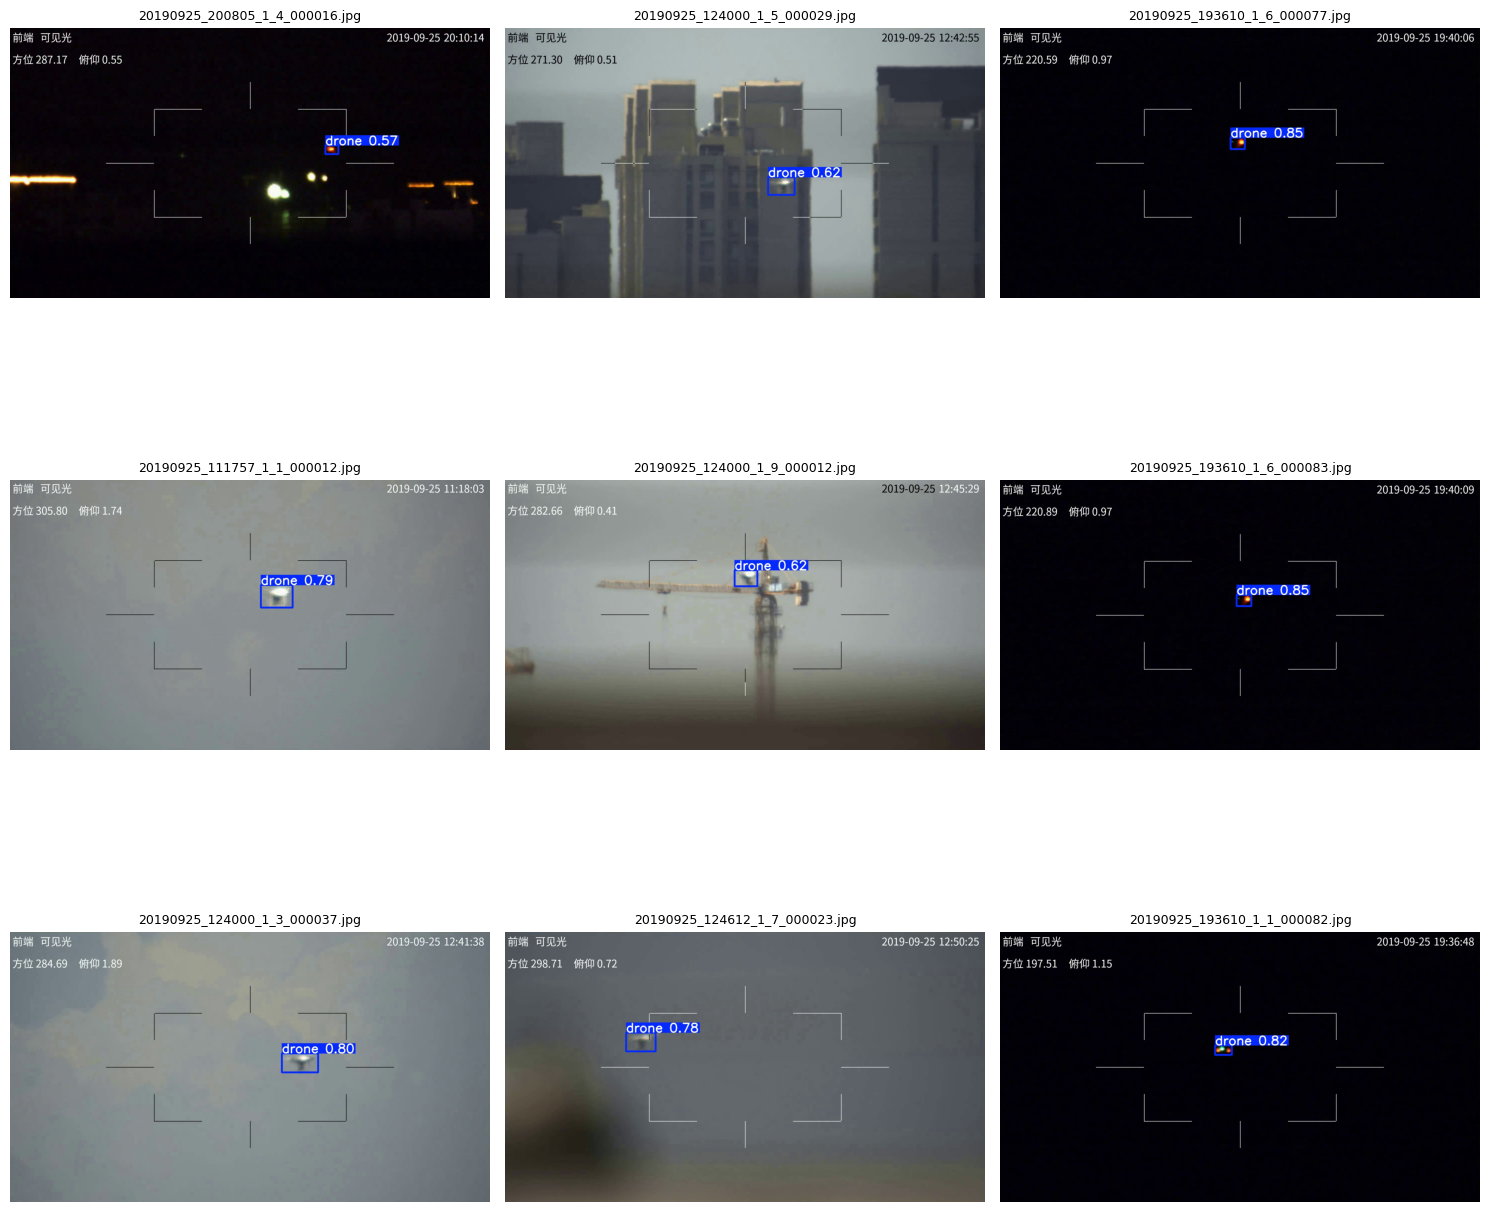

In [11]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pred_dir = Path("/kaggle/working/runs/detect/predict")

images = random.sample(list(pred_dir.glob("*.jpg")), 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, img_path in zip(axes.ravel(), images):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## CROSS-TEST on DRONEDTECT2021 TESTDATA

In [4]:
from ultralytics import YOLO
from pathlib import Path
import random

# Load trained model
model = YOLO(r"D:\DELL\Desktop\Drones_training_results\Anti_UAV_YOLO11m\exp1\weights\best.pt")

# Test images folder
test_dir = Path(r"D:\DELL\Desktop\Drone_Datasets\Full_Dataset\DroneDetection2021_YOLO_Unified\Drones\images\all")

# Get only images
image_files = list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.png"))

# Select random images
sample_images = random.sample(image_files, min(20, len(image_files)))

print("Testing images:")
for img in sample_images:
    print(img.name)

# Prediction
results = model.predict(
    source=[str(img) for img in sample_images],
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    project=r"D:\DELL\Desktop\Drones_training_results\Anti_UAV_YOLO11m\exp1\test_results",
    name="cross-test-predictions_on_dronedetect2021",
    device=0
)

print("Done! Results saved in:")
print(r"D:\DELL\Desktop\Drones_training_results\Anti_UAV_YOLO11m\exp1\test_results\cross-test-predictions_on_dronedetect2021")

Testing images:
V_DRONE_043__frame_000106.jpg
V_DRONE_077__frame_000286.jpg
V_DRONE_003__frame_000031.jpg
V_DRONE_097__frame_000166.jpg
V_DRONE_081__frame_000126.jpg
V_DRONE_084__frame_000216.jpg
V_DRONE_073__frame_000091.jpg
V_DRONE_021__frame_000126.jpg
V_DRONE_082__frame_000101.jpg
V_DRONE_014__frame_000271.jpg
V_DRONE_090__frame_000046.jpg
V_DRONE_011__frame_000286.jpg
V_DRONE_041__frame_000316.jpg
V_DRONE_027__frame_000171.jpg
V_DRONE_006__frame_000046.jpg
V_DRONE_009__frame_000166.jpg
V_DRONE_011__frame_000151.jpg
V_DRONE_087__frame_000046.jpg
V_DRONE_068__frame_000241.jpg
V_DRONE_086__frame_000221.jpg

0: 512x640 (no detections), 30.3ms
1: 512x640 1 drone, 30.3ms
2: 512x640 1 drone, 30.3ms
3: 512x640 (no detections), 30.3ms
4: 512x640 1 drone, 30.3ms
5: 512x640 (no detections), 30.3ms
6: 512x640 (no detections), 30.3ms
7: 512x640 1 drone, 30.3ms
8: 512x640 (no detections), 30.3ms
9: 512x640 1 drone, 30.3ms
10: 512x640 (no detections), 30.3ms
11: 512x640 (no detections), 30.3ms
1


WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
0: 1088x1088 1 drone, 501.9ms
1: 1088x1088 (no detections), 501.9ms
2: 1088x1088 1 drone, 501.9ms
3: 1088x1088 1 drone, 501.9ms
4: 1088x1088 3 drones, 501.9ms
5: 1088x1088 1 drone, 501.9ms
Speed: 18.8ms preprocess, 501.9ms inference, 1.1ms postprocess per image at shape (1, 3, 1088, 1088)


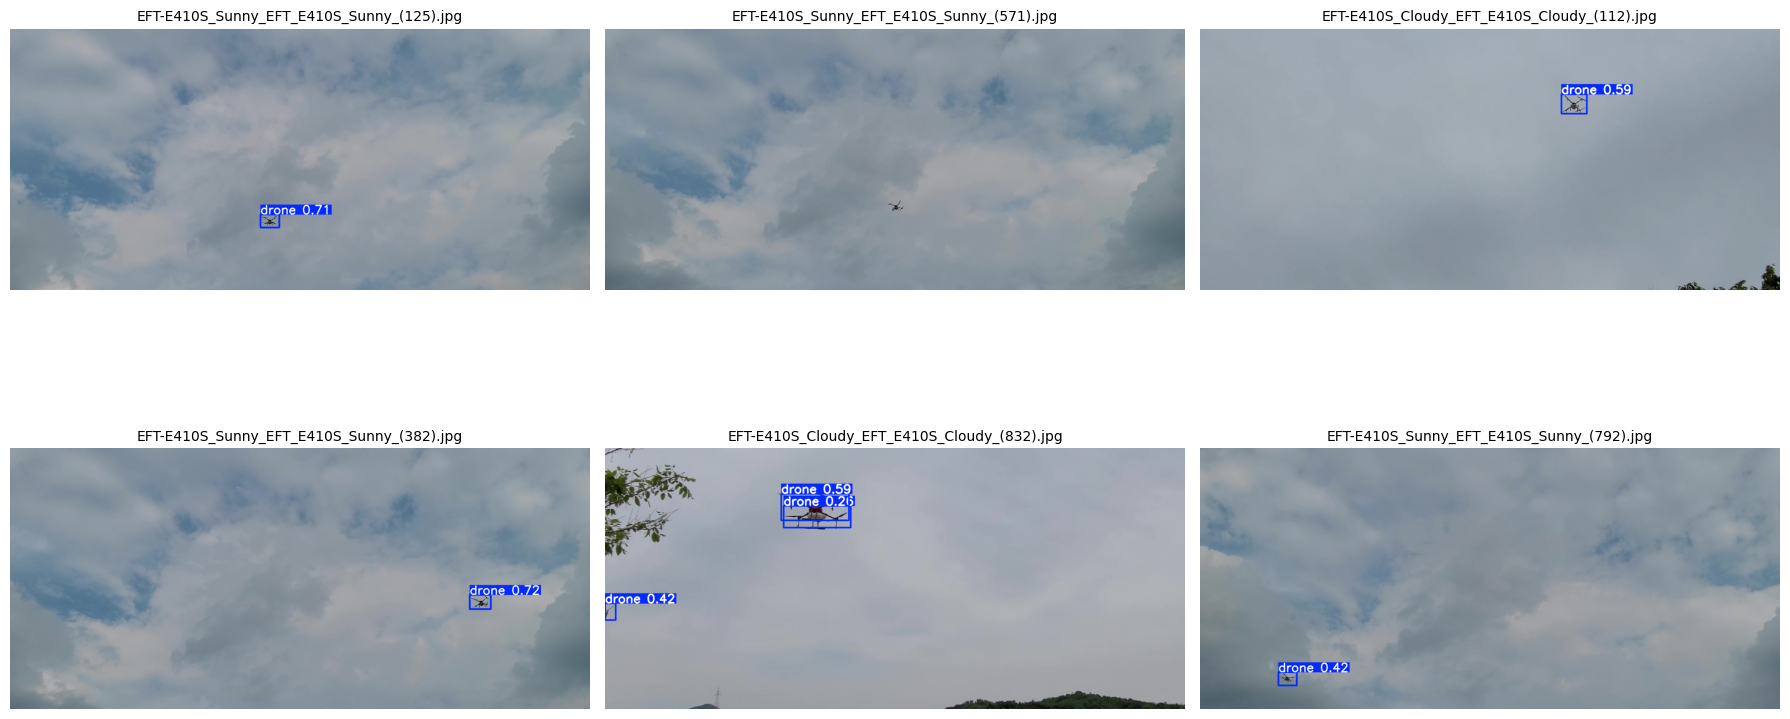

In [20]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt

model = YOLO(r"D:\DELL\Desktop\Drones_training_results\Anti_UAV_YOLO11m\exp1\weights\best.pt")

test_dir = Path(r"D:\DELL\Desktop\Drones_training_results\Drone_Datasets\Full_Dataset\VisioDECT_YOLO_GroupSplit\images\test")

image_files = list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.png"))

sample_images = random.sample(image_files, 6)

results = model.predict(
    source=[str(img) for img in sample_images],
    imgsz=1080,
    conf=0.25,
    save=False,      # no need to save
    device=0
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, result, img_path in zip(axes, results, sample_images):
    annotated = result.plot()          # BGR image
    annotated = annotated[:, :, ::-1]  # Convert BGR → RGB

    ax.imshow(annotated)
    ax.set_title(img_path.name, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()